# **1. Segmentation**
Segmentation은 컴퓨터 비전에서 이미지나 영상을 픽셀 단위로 분할하여 각 영역이 무엇을 나타내는지 구분하는 기술입니다. 이는 크게 Semantic Segmentation과 Instance Segmentation으로 나뉘는데, Semantic Segmentation은 같은 종류의 객체를 동일한 클래스로 분류하는 반면, Instance Segmentation은 같은 클래스 내에서도 개별 객체를 구분합니다. 이를 통해 의료 영상 분석, 자율주행, 위성 이미지 처리 등 다양한 분야에서 정밀한 객체 인식을 수행할 수 있습니다. Segmentation 모델로는 U-Net, DeepLab, Mask R-CNN 등이 널리 사용됩니다.
![세그멘테이션](./images/세그멘테이션.png)

icrawler

# **2. 스타벅스 데이터셋**

### COCO JSON
- images: 이미지 ID, 파일명, width, height
- annotations: 객체의 category, polygon, bbox(바운딩박스)등
- categories: 클래스 ID와 이름


```
{
  "images": [ ... ],       // 이미지 메타정보 리스트
  "annotations": [ ... ],  // 박스/라벨 정보 리스트
  "categories": [ ... ],   // 클래스(카테고리) 정의 리스트
  "info": { ... },         // 데이터셋 설명 (선택)
  "licenses": [ ... ]      // 라이선스 정보 (선택)
}
```

In [3]:
import json
import random
import shutil
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import ultralytics
import yaml

from ultralytics import YOLO

In [4]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
SOURCE_DIR = DATA_ROOT / 'Starbucks'
YOLO_ROOT = DATA_ROOT / 'Starbucks_YOLO'
COCO_JSON = SOURCE_DIR / 'instances_default.json'

print('PROJECT_ROOT: ',PROJECT_ROOT)
print('DATA_ROOT: ',DATA_ROOT)
print('SOURCE_DIR: ',SOURCE_DIR)
print('YOLO_ROOT: ',YOLO_ROOT)
print('COCO_JSON: ',COCO_JSON)

PROJECT_ROOT:  c:\harwoon\11_CV
DATA_ROOT:  c:\harwoon\11_CV\data
SOURCE_DIR:  c:\harwoon\11_CV\data\Starbucks
YOLO_ROOT:  c:\harwoon\11_CV\data\Starbucks_YOLO
COCO_JSON:  c:\harwoon\11_CV\data\Starbucks\instances_default.json


In [5]:
with COCO_JSON.open("r",encoding='utf-8') as f:
    coco_data = json.load(f)

coco_data

{'licenses': [{'name': '', 'id': 0, 'url': ''}],
 'info': {'contributor': '',
  'date_created': '',
  'description': '',
  'url': '',
  'version': '',
  'year': ''},
 'categories': [{'id': 1, 'name': 'logo', 'supercategory': ''},
  {'id': 2, 'name': 'text', 'supercategory': ''}],
 'images': [{'id': 1,
   'width': 1024,
   'height': 682,
   'file_name': '000001.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 2,
   'width': 885,
   'height': 960,
   'file_name': '000002.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 3,
   'width': 1600,
   'height': 1155,
   'file_name': '000003.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 4,
   'width': 1300,
   'height': 956,
   'file_name': '000004.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 5,
   'width': 900,
   'height': 1200,
   'file_name': '000005.j

In [6]:
# category ID가 반드시 연속이라는 보장이 없음
# 오름차순으로 정렬
categories = sorted(coco_data['categories'], key=lambda x: x['id'])

COCO_ID_TO_YOLO_ID = {
    category['id']: yolo_id for yolo_id, category in enumerate(categories)
}

CLASS_NAMES = [category['name'] for category in categories]

print('이미지 수: ',len(coco_data['images']))
print('Annotation 수: ', len(coco_data['annotations']))
print('클래스: ', CLASS_NAMES)
print('ID 매핑: ', COCO_ID_TO_YOLO_ID)

이미지 수:  612
Annotation 수:  1296
클래스:  ['logo', 'text']
ID 매핑:  {1: 0, 2: 1}


### 이미지와 Annotation 확인
- JSON에 등록된 이미지가 실제 폴더에 모두 존재하는지 확인
- 클래스별 annotation 수를 확인하면 특정 클래스가 지나치게 적은지도 확인할 수 있음

In [7]:
image_info_by_id = {image_info['id']:image_info for image_info in coco_data['images']}

missing_images = []

for image_info in coco_data['images']:
    image_path = SOURCE_DIR / image_info['file_name']
    if not image_path.exists():
        missing_images.append(image_info['file_name'])

class_counts = Counter(
    COCO_ID_TO_YOLO_ID[ann['category_id']] for ann in coco_data['annotations']
    if ann['category_id'] in COCO_ID_TO_YOLO_ID)

print('누락 이미지 수: ',len(missing_images))
if missing_images:
    print(missing_images)

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f'{class_id}: {class_name} > {class_counts[class_id]} annotations')

누락 이미지 수:  0
0: logo > 933 annotations
1: text > 363 annotations


### COCO Polygon Annotation 시각화
- COCO Polygon Annotation의 좌표
```
[x1, y1, x2, y2, x3, y3, ...]
최소 3개의 점을 연결하여 객체 외곽을 표현
```

In [8]:
def load_rgb_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'이미지를 읽을 수 없습니다: {image_path}')
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [ ]:
def visualize_coco_annotation(image_id: int):
    image_info = image_info_by_id.get(image_id)
    if image_info is None:
        raise ValueError(f'존재하지 않는 image_id입니다: {image_id}')
    
    image = load_rgb_image(SOURCE_DIR / image_info['file_name']).copy()

    for ann in coco_data['annotations']:
        if ann['image_id'] != image_id:
            continue

        class_id = COCO_ID_TO_YOLO_ID[ann['category_id']]
        class_name = CLASS_NAMES[class_id]

        for polygon in ann.get("segmentation", []):
            if not isinstance(polygon, list) or len(polygon) < 6:
                continue

            points = np.array(polygon, dtype=np.float32).reshape(-1,2).astype(np.int32) # 2개씩 묶는데 총 몇 개일지는 몰라 -1

            cv2.polylines(image, [points], True, (0,255,0), 2)

            x, y= points[0]
            cv2.putText(image, class_name, (int(x), max(20, int(y)-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
        
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'COCO Annotation - {image_info['file_name']}')
    plt.show()
        

    

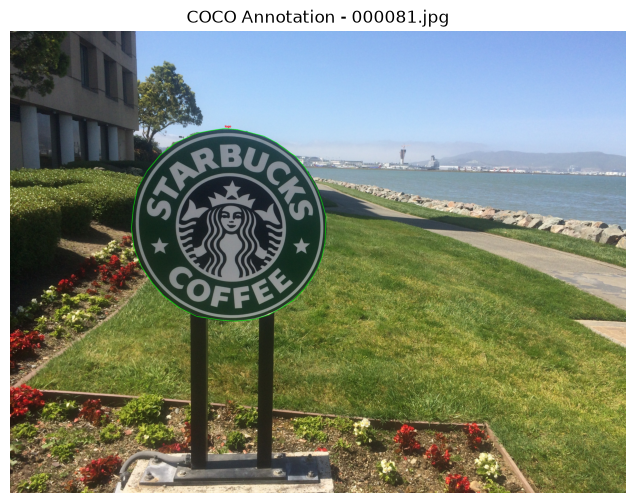

In [38]:
visualize_coco_annotation(image_id=81)

### COCO > YOLO Segmentation 변환

YOLO Segmentation 라벨
```
class_id x1 y1 x2 y2 x3 y3 ...
```
좌표는 픽셀 값이 아니라 0 ~ 1 사이로 정규화

- x_norm = x / image_width
- y_norm = y / image_height

In [29]:
def coco_polygon_to_yolo_line(class_id, polygon, image_width, imgae_height):
    if not isinstance(polygon, list) or len(polygon) < 6: #좌표가 3개가 안되면
        return None

    if len(polygon) % 2 != 0:
        return None

    normalized_values = []

    for i in range(0, len(polygon),2):
        x = polygon[i]
        y = polygon[i + 1]
        x_norm = x / image_width
        y_norm = y / imgae_height

        x_norm = min(max(x_norm, 0.0), 1.0) # 방어 코드
        y_norm = min(max(y_norm, 0.0), 1.0)
        normalized_values.extend([x_norm, y_norm])

    coordinates = " ".join(f'{value:.6f}' for value in normalized_values)
    return f'{class_id} {coordinates}'

### train / val / test 분할 

In [31]:
SEED = 2026
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2

random.seed(SEED)

all_images = [image_info for image_info in coco_data['images']
              if(SOURCE_DIR / image_info['file_name']).exists()]

random.shuffle(all_images)
num_images = len(all_images)
num_train = int(num_images * TRAIN_RATIO)
num_val = int(num_images * VAL_RATIO)

train_images = all_images[:num_train]
val_images = all_images[num_train:num_train+num_val]
test_images = all_images[num_train+num_val:]

print('전체: ', num_images)
print("train: ", len(train_images))
print("val: ", len(val_images))
print("test: ", len(test_images))

전체:  612
train:  367
val:  122
test:  123


### YOLO 폴더 구조 생성
- YOLO의 명확한 구조는 이미지와 라벨을 분리하는 방식
- 예) images / train / starbucks11.jpg > labels/train/starbucks11.txt

In [32]:
def prepare_yolo_split(split_name, split_images):
    image_output_dir = YOLO_ROOT / 'images' / split_name
    label_output_dir = YOLO_ROOT / 'labels' / split_name

    image_output_dir.mkdir(parents=True, exist_ok=True)
    label_output_dir.mkdir(parents=True, exist_ok=True)

    # 재실행할 때 과거 파일이 남아 섞이는 것을 방지
    for old_file in image_output_dir.iterdir():
        if old_file.is_file():
            old_file.unlink()

    for old_file in label_output_dir.iterdir():
        if old_file.is_file():
            old_file.unlink()

    annotations_by_image = {}

    for ann in coco_data['annotations']:
        annotations_by_image.setdefault(ann['image_id'], []).append(ann)

    for image_info in split_images:
        image_id = image_info['id']
        image_width = image_info['width']
        image_height = image_info['height']
        file_name = image_info['file_name']

        shutil.copy2(SOURCE_DIR / file_name , image_output_dir / file_name)

        yolo_lines = []

        for ann in annotations_by_image.get(image_id, []):
            coco_category_id = ann['category_id']
            if coco_category_id not in COCO_ID_TO_YOLO_ID:
                continue
            class_id = COCO_ID_TO_YOLO_ID[coco_category_id]
            segmentation = ann.get('segmentation', [])

            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                yolo_line = coco_polygon_to_yolo_line(class_id, polygon, image_width, image_height)

                if yolo_line is not None:
                    yolo_lines.append(yolo_line)

        label_path = label_output_dir / f'{Path(file_name).stem}.txt'
        if yolo_lines:
            label_path.write_text("\n".join(yolo_lines), encoding='utf-8')


In [33]:
prepare_yolo_split('train', train_images)
prepare_yolo_split('val', val_images)
prepare_yolo_split('test', test_images)
print('COCO > YOLO Segmentation 변경 완료')

COCO > YOLO Segmentation 변경 완료


### YOLO txt 라벨 다시 시각화
- COCO JSON이 아니라 변환된 YOLO txt를 읽어서 polygon을 그림

In [ ]:
LABEL_ROOT = YOLO_ROOT / 'labels' / 'train' / '000002.txt'

with LABEL_ROOT.open("r",encoding='utf-8') as f:
    lines = f.readlines()

['0 0.509729 0.321344 0.455096 0.329740 0.409582 0.340531 0.358847 0.354917 0.306825 0.376500 0.248294 0.404073 0.198870 0.432854 0.165051 0.452042 0.135141 0.470021 0.116927 0.497604 0.118226 0.544365 0.129932 0.571948 0.178056 0.556354 0.223582 0.547958 0.262599 0.550365 0.300316 0.564750 0.330237 0.586333 0.340644 0.619906 0.327638 0.655875 0.297718 0.695448 0.270407 0.732615 0.258701 0.742208 0.301627 0.773385 0.331537 0.790167 0.384859 0.808156 0.431684 0.817750 0.481107 0.818948 0.524034 0.814146 0.568260 0.804552 0.618983 0.782979 0.664508 0.754198 0.700927 0.721823 0.729537 0.683458 0.746441 0.657073 0.764655 0.616312 0.775062 0.574344 0.778960 0.523979 0.773763 0.476021 0.755548 0.422063 0.734746 0.387292 0.715232 0.359708 0.678814 0.336927 0.638497 0.322542 0.590373 0.316552 0.546147 0.316552']


### YOLO 데이터셋 YAML 생성

### YOLO11 Segmentation 모델 불러오기